# Лабораторная работа №4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataframe = pd.read_csv("../lab4/data/DataBikes_new.csv")
dataframe = dataframe.drop(columns=["Unnamed: 0"])
display(dataframe)
dataframe.info()

,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category
0,01/12/2017,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,257,56.0,0-100,frost
1,01/12/2017,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,219,3.0,0-10,frost
2,01/12/2017,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,162,7.0,0-10,frost
3,01/12/2017,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,148,8.0,0-10,frost
4,01/12/2017,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,97,10.0,0-100,frost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,Yes,644,55.0,0-100,cold
8756,30/11/2018,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,Yes,359,10.0,0-100,cold
8757,30/11/2018,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,Yes,1236,8.0,0-10,cold
8758,30/11/2018,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,Yes,628,8.0,0-10,cold


<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  8760 non-null   str    
 1   Hour                  8760 non-null   int64  
 2   Temperature           8581 non-null   float64
 3   Humidity              8760 non-null   int64  
 4   Wind speed            8760 non-null   float64
 5   Rainfall              8760 non-null   float64
 6   Snowfall              8760 non-null   float64
 7   Seasons               8760 non-null   str    
 8   Holiday               8760 non-null   str    
 9   Functioning Day       8760 non-null   str    
 10  Rental count          8760 non-null   int64  
 11  score                 8760 non-null   float64
 12  score_type            8760 non-null   str    
 13  Temperature Category  8581 non-null   str    
dtypes: float64(5), int64(3), str(6)
memory usage: 958.3 KB


1) Проанализируйте переменные (столбцы) и укажите, для каких из них определение числовых характеристик имеет смысл. Понимать значения всех характеристик, которые дает метод describe().

In [3]:
dataframe.describe()

,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Rental count,score
count,8760.000000,8581.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,11.500000,12.878557,58.226256,1.724909,0.148687,0.075068,696.582078,31.619406
std,6.922582,11.955551,20.362413,1.036300,1.128193,0.436746,749.812613,31.716206
min,0.000000,-17.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.750000,3.400000,42.000000,0.900000,0.000000,0.000000,157.000000,8.000000
50%,11.500000,13.700000,57.000000,1.500000,0.000000,0.000000,425.500000,10.000000
75%,17.250000,22.500000,74.000000,2.300000,0.000000,0.000000,1009.000000,61.000000
max,23.000000,39.400000,98.000000,7.400000,35.000000,8.800000,6012.000000,100.000000


2) Для каждого сезона найдите: среднюю, медианную и модовую температуры, дисперсию, среднеквадратичное отклонение, размах и интерквартильный размах температуры. Результат также выведите в виде общей таблицы.

In [4]:
seasons_temperature = dataframe.groupby('Seasons')['Temperature']
mean_temperature = seasons_temperature.mean()
median_temperature = seasons_temperature.median()
mode_temperature = seasons_temperature.apply(lambda x: x.mode().tolist())

var_temperature = seasons_temperature.var()
std_temperature = seasons_temperature.std()
dif_temperature = seasons_temperature.apply(lambda x: abs(x.max() - x.min()))
quantile_dif_temperature = seasons_temperature.quantile(0.75) - seasons_temperature.quantile(0.25)

distribution_dataframe = pd.DataFrame()

distribution_dataframe['Средняя температура'] = mean_temperature
distribution_dataframe['Медианная температура'] = median_temperature
distribution_dataframe['Модовая температура'] = mode_temperature
distribution_dataframe['Дисперсия'] = var_temperature
distribution_dataframe['Среднеквадратичное отклонение'] = std_temperature
distribution_dataframe['Размах'] = dif_temperature
distribution_dataframe['Интерквартильный размах'] = quantile_dif_temperature
distribution_dataframe = distribution_dataframe
distribution_dataframe

,Средняя температура,Медианная температура,Модовая температура,Дисперсия,Среднеквадратичное отклонение,Размах,Интерквартильный размах
Seasons,,,,,,,
Autumn,14.138821,13.8,"[10.8, 16.6]",49.589573,7.041986,33.5,11.1
Spring,13.038533,13.3,[9.6],43.665630,6.607997,36.0,9.9
Summer,26.574827,26.6,"[23.4, 24.2, 24.6]",21.655814,4.653581,23.1,6.7
Winter,-2.567783,-2.2,"[-1.8, -1.3]",29.877730,5.466052,28.1,7.7


3) Переменная «Temperature» содержит None значения. Предложите и реализуйте способ их замены, который по Вашему мнению будет наиболее достоверно соответствовать реальным условиям. Определите, как изменятся при этом числовые характеристики среднего и разброса для температуры.

In [5]:
dataframe['Date'] = pd.to_datetime(dataframe['Date'], format='%d/%m/%Y')

dataframe['Week'] = dataframe['Date'].dt.isocalendar().week

dataframe['Temperature'] = dataframe['Temperature'].fillna(dataframe.groupby(['Week', 'Hour'])['Temperature'].transform('mean'))

new_seasons_temperature = dataframe.groupby('Seasons')['Temperature']
new_mean_temperature = new_seasons_temperature.mean()
new_median_temperature = new_seasons_temperature.median()
new_mode_temperature = new_seasons_temperature.apply(lambda x: x.mode().tolist())
new_var_temperature = new_seasons_temperature.var()
new_std_temperature = new_seasons_temperature.std()
new_dif_temperature = new_seasons_temperature.apply(lambda x: abs(x.max() - x.min()))
new_quantile_dif_temperature = new_seasons_temperature.quantile(0.75) - new_seasons_temperature.quantile(0.25)

new_distribution_dataframe = pd.DataFrame()

new_distribution_dataframe['Средняя температура'] = new_mean_temperature
new_distribution_dataframe['Медианная температура'] = new_median_temperature
new_distribution_dataframe['Модовая температура'] = new_mode_temperature
new_distribution_dataframe['Дисперсия'] = new_var_temperature
new_distribution_dataframe['Среднеквадратичное отклонение'] = new_std_temperature
new_distribution_dataframe['Размах'] = new_dif_temperature
new_distribution_dataframe['Интерквартильный размах'] = new_quantile_dif_temperature
display(new_distribution_dataframe)

dif_distribution_dataframe = pd.DataFrame()
dif_distribution_dataframe['Средняя температура'] = abs(new_mean_temperature - mean_temperature)
dif_distribution_dataframe['Медианная температура'] = abs(new_median_temperature - median_temperature)
dif_distribution_dataframe['Модовая температура'] = new_mode_temperature
dif_distribution_dataframe['Дисперсия'] = abs(new_var_temperature - var_temperature)
dif_distribution_dataframe['Среднеквадратичное отклонение'] = abs(new_std_temperature - std_temperature)
dif_distribution_dataframe['Размах'] = abs(new_dif_temperature - dif_temperature)
dif_distribution_dataframe['Интерквартильный размах'] = abs(new_quantile_dif_temperature - quantile_dif_temperature)
display(dif_distribution_dataframe)

,Средняя температура,Медианная температура,Модовая температура,Дисперсия,Среднеквадратичное отклонение,Размах,Интерквартильный размах
Seasons,,,,,,,
Autumn,14.109791,13.8,"[10.8, 16.6]",49.846580,7.060211,33.5,11.2
Spring,13.054226,13.3,[9.6],43.403266,6.588116,36.0,9.7
Summer,26.578191,26.6,"[23.4, 24.2, 24.6]",21.621408,4.649883,23.1,6.7
Winter,-2.547833,-2.2,"[-1.8, -1.3]",29.766521,5.455870,28.1,7.6


,Средняя температура,Медианная температура,Модовая температура,Дисперсия,Среднеквадратичное отклонение,Размах,Интерквартильный размах
Seasons,,,,,,,
Autumn,0.029030,0.0,"[10.8, 16.6]",0.257006,0.018225,0.0,0.1
Spring,0.015693,0.0,[9.6],0.262364,0.019882,0.0,0.2
Summer,0.003364,0.0,"[23.4, 24.2, 24.6]",0.034406,0.003698,0.0,0.0
Winter,0.019950,0.0,"[-1.8, -1.3]",0.111209,0.010182,0.0,0.1


4) Предположим, что наблюдения температуры, отклоняющиеся от средней температуры для каждого сезона более чем на два стандартных отклонения, являются выбросами. Сформируйте таблицу без выбросов. Установить, будет ли наблюдаться отличие в характеристиках средних для температуры, построенных на основе исходной и новой таблиц.

In [6]:
without_outliers_dataframe = dataframe.merge(new_distribution_dataframe[['Средняя температура', 'Среднеквадратичное отклонение']], on='Seasons')
without_outliers_dataframe['Temperature diff'] = abs(without_outliers_dataframe['Temperature'] - without_outliers_dataframe['Средняя температура'])
without_outliers_dataframe = without_outliers_dataframe[without_outliers_dataframe['Temperature diff'] < 2 * without_outliers_dataframe['Среднеквадратичное отклонение']]
display(without_outliers_dataframe)

without_outliers_temperature_dataframe = without_outliers_dataframe.groupby('Seasons')['Temperature']
without_outliers_mean_temperature = without_outliers_temperature_dataframe.mean()
without_outliers_median_temperature = without_outliers_temperature_dataframe.median()
without_outliers_mode_temperature = without_outliers_temperature_dataframe.apply(lambda x: x.mode().tolist())

without_outliers_var_temperature = without_outliers_temperature_dataframe.var()
without_outliers_std_temperature = without_outliers_temperature_dataframe.std()
without_outliers_dif_temperature = without_outliers_temperature_dataframe.apply(lambda x: abs(x.max() - x.min()))
without_outliers_quantile_dif_temperature = without_outliers_temperature_dataframe.quantile(0.75) - without_outliers_temperature_dataframe.quantile(0.25)

without_outliers_distribution_dataframe = pd.DataFrame()

without_outliers_distribution_dataframe['Средняя температура'] = without_outliers_mean_temperature
without_outliers_distribution_dataframe['Медианная температура'] = without_outliers_median_temperature
without_outliers_distribution_dataframe['Модовая температура'] = without_outliers_mode_temperature
without_outliers_distribution_dataframe['Дисперсия'] = without_outliers_var_temperature
without_outliers_distribution_dataframe['Среднеквадратичное отклонение'] = without_outliers_std_temperature
without_outliers_distribution_dataframe['Размах'] = without_outliers_dif_temperature
without_outliers_distribution_dataframe['Интерквартильный размах'] = without_outliers_quantile_dif_temperature
display(without_outliers_distribution_dataframe)

without_outliers_dif_distribution_dataframe = pd.DataFrame()
without_outliers_dif_distribution_dataframe['Средняя температура'] = abs(without_outliers_mean_temperature - mean_temperature)
without_outliers_dif_distribution_dataframe['Медианная температура'] = abs(without_outliers_median_temperature - median_temperature)
without_outliers_dif_distribution_dataframe['Модовая температура'] = without_outliers_mode_temperature
without_outliers_dif_distribution_dataframe['Дисперсия'] = abs(without_outliers_var_temperature - var_temperature)
without_outliers_dif_distribution_dataframe['Среднеквадратичное отклонение'] = abs(without_outliers_std_temperature - std_temperature)
without_outliers_dif_distribution_dataframe['Размах'] = abs(without_outliers_dif_temperature - dif_temperature)
without_outliers_dif_distribution_dataframe['Интерквартильный размах'] = abs(without_outliers_quantile_dif_temperature - quantile_dif_temperature)
display(without_outliers_dif_distribution_dataframe)

,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category,Week,Средняя температура,Среднеквадратичное отклонение,Temperature diff
0,2017-12-01,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,257,56.0,0-100,frost,48,-2.547833,5.455870,2.652167
1,2017-12-01,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,219,3.0,0-10,frost,48,-2.547833,5.455870,2.952167
2,2017-12-01,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,162,7.0,0-10,frost,48,-2.547833,5.455870,3.452167
3,2017-12-01,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,148,8.0,0-10,frost,48,-2.547833,5.455870,3.652167
4,2017-12-01,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,97,10.0,0-100,frost,48,-2.547833,5.455870,3.452167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,Yes,644,55.0,0-100,cold,48,14.109791,7.060211,9.909791
8756,2018-11-30,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,Yes,359,10.0,0-100,cold,48,14.109791,7.060211,10.709791
8757,2018-11-30,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,Yes,1236,8.0,0-10,cold,48,14.109791,7.060211,11.509791
8758,2018-11-30,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,Yes,628,8.0,0-10,cold,48,14.109791,7.060211,12.009791


,Средняя температура,Медианная температура,Модовая температура,Дисперсия,Среднеквадратичное отклонение,Размах,Интерквартильный размах
Seasons,,,,,,,
Autumn,14.174539,13.9,"[10.8, 16.6]",46.854003,6.844998,28.2,11.0
Spring,13.052143,13.3,[9.6],38.989534,6.244160,26.1,9.6
Summer,26.357007,26.4,"[23.4, 24.2, 24.6]",19.008569,4.359882,18.4,6.4
Winter,-2.158635,-2.0,"[-1.8, -1.3]",24.667034,4.966592,21.6,7.3


,Средняя температура,Медианная температура,Модовая температура,Дисперсия,Среднеквадратичное отклонение,Размах,Интерквартильный размах
Seasons,,,,,,,
Autumn,0.035717,0.1,"[10.8, 16.6]",2.735570,0.196988,5.3,0.1
Spring,0.013610,0.0,[9.6],4.676096,0.363837,9.9,0.3
Summer,0.217820,0.2,"[23.4, 24.2, 24.6]",2.647245,0.293699,4.7,0.3
Winter,0.409148,0.2,"[-1.8, -1.3]",5.210696,0.499461,6.5,0.4


5) На одном графике построить размах для каждого месяца. Подписать название графика и его оси.

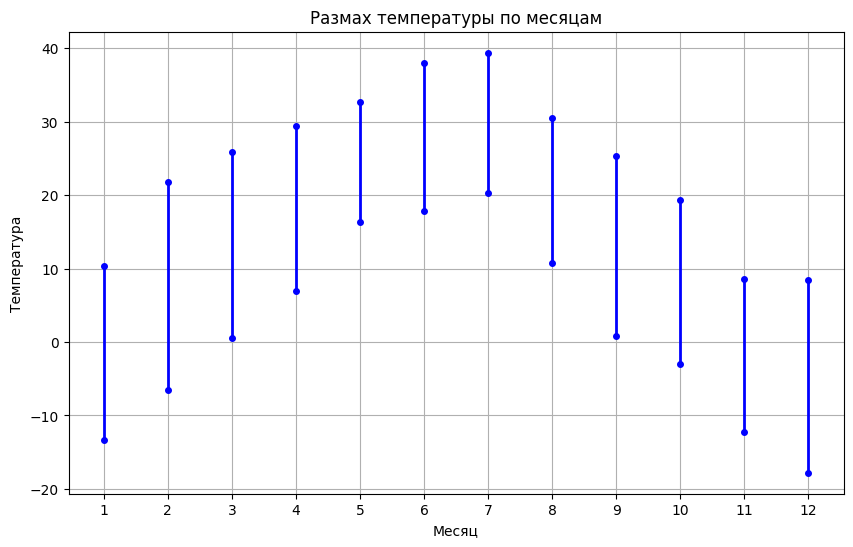

In [7]:
dataframe['Date'] = pd.to_datetime(dataframe['Date'], format='%d/%m/%Y')
dataframe['Month'] = dataframe['Date'].dt.month
month_temperature = dataframe.groupby('Month')['Temperature']

month_max_temperature = month_temperature.max().tolist()
month_min_temperature = month_temperature.min().tolist()
month = dataframe['Month'].unique().tolist()

plt.figure(figsize=(10, 6))
plt.title('Размах температуры по месяцам')
plt.plot([month, month], [month_min_temperature, month_max_temperature], 'b-o', linewidth=2, markersize=4)
plt.xlabel('Месяц')
plt.ylabel('Температура')
plt.grid(True)
plt.xticks(month)
plt.show()

6) Найдите, сколько дней работа проката по оценкам была выше среднего. В этом случае следует учитывать, что оценки выставлялись по разным шкалам, поэтому 10 по одной шкале это отлично, а по другой очень плохо. Для решения этой проблемы используют так называемую «z-стандартизацию», т. е. вводят новую переменную

$$z = \frac{x - m} {σ}$$

которая показывает на сколько среднеквадратичных $x$ отклонений отклоняется от среднего.

In [8]:
scale_rating = dataframe.groupby('score_type')['score']
scale_rating_mean = scale_rating.mean()
scale_rating_std = scale_rating.std()

stats = pd.DataFrame()
stats['score_mean'] = scale_rating_mean
stats['score_std'] = scale_rating_std

z_dataframe = dataframe.merge(stats, on='score_type')

z_dataframe['z-standardization'] = (z_dataframe['score'] - z_dataframe['score_mean']) / z_dataframe['score_std']
display(z_dataframe)

days_count = z_dataframe[z_dataframe['z-standardization'] > 0].shape[0]
print(f"Количество дней, когда работа проката по оценкам была выше среднего - {days_count}")

,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Rental count,score,score_type,Temperature Category,Week,Month,score_mean,score_std,z-standardization
0,2017-12-01,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,257,56.0,0-100,frost,48,12,44.552083,32.218213,0.355324
1,2017-12-01,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,219,3.0,0-10,frost,48,12,6.788667,2.571681,-1.473226
2,2017-12-01,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,162,7.0,0-10,frost,48,12,6.788667,2.571681,0.082177
3,2017-12-01,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,148,8.0,0-10,frost,48,12,6.788667,2.571681,0.471028
4,2017-12-01,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,97,10.0,0-100,frost,48,12,44.552083,32.218213,-1.072439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,19,4.2,34,2.6,0.0,0.0,Autumn,No Holiday,Yes,644,55.0,0-100,cold,48,11,44.552083,32.218213,0.324286
8756,2018-11-30,20,3.4,37,2.3,0.0,0.0,Autumn,No Holiday,Yes,359,10.0,0-100,cold,48,11,44.552083,32.218213,-1.072439
8757,2018-11-30,21,2.6,39,0.3,0.0,0.0,Autumn,No Holiday,Yes,1236,8.0,0-10,cold,48,11,6.788667,2.571681,0.471028
8758,2018-11-30,22,2.1,41,1.0,0.0,0.0,Autumn,No Holiday,Yes,628,8.0,0-10,cold,48,11,6.788667,2.571681,0.471028


Количество дней, когда работа проката по оценкам была выше среднего - 4619


7) Установить наличие линейной зависимости между температурой и числом арендованных велосипедов (по данным за весь год, по сезонам, по месяцам). Для данных, имеющих максимальную линейную зависимость, построить график рассеяния.

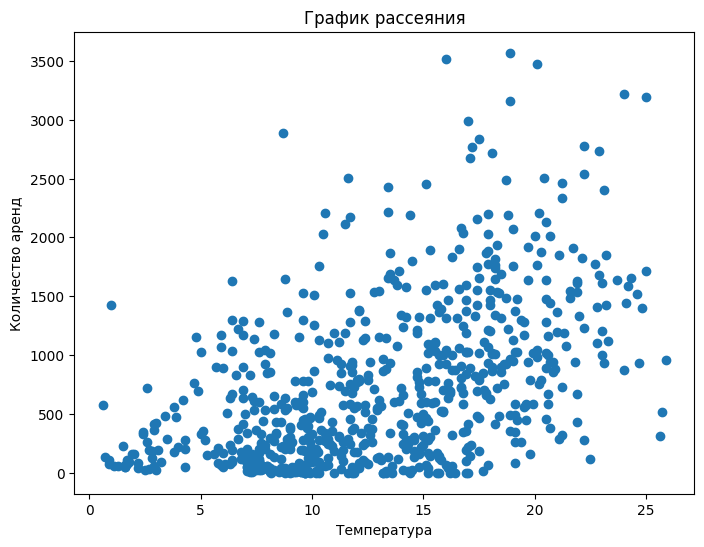

In [9]:
dataframe['Year'] = dataframe['Date'].dt.year

year_temperature_corr = dataframe.groupby('Year')['Temperature'].corr(dataframe['Rental count'])

season_temperature_corr = dataframe.groupby('Seasons')['Temperature'].corr(dataframe['Rental count'])

month_temperature_corr = dataframe.groupby('Month')['Temperature'].corr(dataframe['Rental count'])

# Максимальная линейная зависимость: Месяц 4 0.503106

max_corr = month_temperature_corr.max()
max_month = month_temperature_corr.idxmax()

plt.figure(figsize=(8, 6))
plt.scatter(dataframe[dataframe['Month'] == max_month]['Temperature'], dataframe[dataframe['Month'] == max_month]['Rental count'])
plt.xlabel('Температура')
plt.ylabel('Количество аренд')
plt.title('График рассеяния')
plt.show()

8) Аналогичные п.7 исследования провести для температуры и оценки.

Линейная зависимость между температурой и оценкой (год, сезон, месяц). График рассеяния для данных, имеющих максимальную линейную зависимость

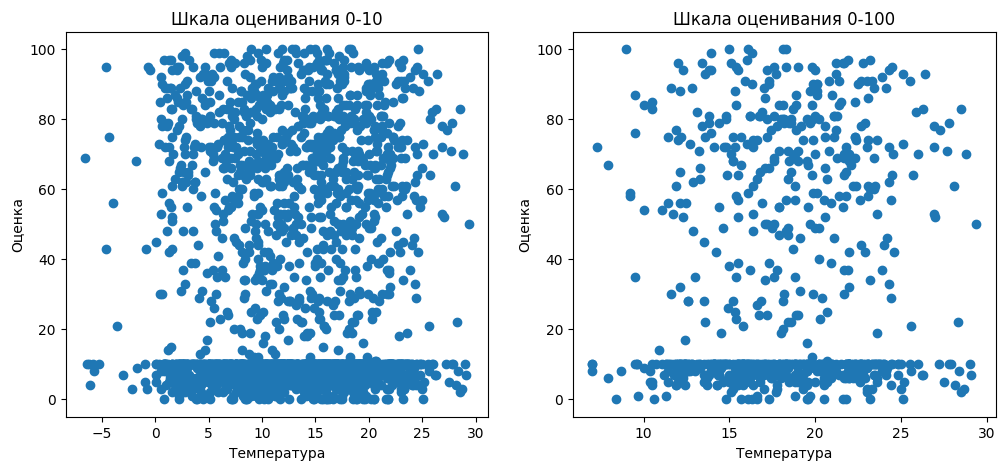

In [10]:
ten_point_scale_dataframe = dataframe[dataframe['score_type'] == '0-10']
hundred_point_scale_dataframe = dataframe[dataframe['score_type'] == '0-100']

year_ten_point_scale_corr = ten_point_scale_dataframe.groupby('Year')['Temperature'].corr(ten_point_scale_dataframe['score'])
season_ten_point_scale_corr = ten_point_scale_dataframe.groupby('Seasons')['Temperature'].corr(ten_point_scale_dataframe['score'])
month_ten_point_scale_corr = ten_point_scale_dataframe.groupby('Month')['Temperature'].corr(ten_point_scale_dataframe['score'])

# Максимальная линейная зависимость: Spring 0.096127

max_ten_point_scale_corr = season_ten_point_scale_corr.max()
max_ten_point_scale_season = season_ten_point_scale_corr.idxmax()

year_hundred_point_scale_corr = hundred_point_scale_dataframe.groupby('Year')['Temperature'].corr(hundred_point_scale_dataframe['score'])
season_hundred_point_scale_corr = hundred_point_scale_dataframe.groupby('Seasons')['Temperature'].corr(hundred_point_scale_dataframe['score'])
month_hundred_point_scale_corr = hundred_point_scale_dataframe.groupby('Month')['Temperature'].corr(hundred_point_scale_dataframe['score'])

# Максимальная линейная зависимость: Месяц 5 0.076585

max_hundred_point_scale_corr = month_hundred_point_scale_corr.max()
max_hundred_point_scale_month = month_hundred_point_scale_corr.idxmax()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(dataframe[dataframe['Seasons'] == max_ten_point_scale_season]['Temperature'], dataframe[dataframe['Seasons'] == max_ten_point_scale_season]['score'])
plt.xlabel('Температура')
plt.ylabel('Оценка')
plt.title('Шкала оценивания 0-10')

plt.subplot(1, 2, 2)
plt.scatter(dataframe[dataframe['Month'] == max_hundred_point_scale_month]['Temperature'], dataframe[dataframe['Month'] == max_hundred_point_scale_month]['score'])
plt.xlabel('Температура')
plt.ylabel('Оценка')
plt.title('Шкала оценивания 0-100')

plt.show()